# Lab 4: Regression and Classification Evaluation Metrics
## Part 1: K-Nearest Neighbours (KNN) Classification using Breast Cancer Dataset

**Objective:** Implement KNN classification on the Breast Cancer dataset and analyze model performance using train-test split, heuristic K selection, cross-validation, ROC-AUC, and classification metrics. Compare with regression metrics from Lab 3.

## Task 1: Data Preparation

Load the Breast Cancer Wisconsin dataset, explore structure, check for missing values and duplicates, and apply feature scaling.

In [1]:
# Task 1: Data Preparation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.decomposition import PCA

RANDOM_STATE = 489
np.random.seed(RANDOM_STATE)

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names  # malignant=0, benign=1

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", target_names)
print("Class distribution:", pd.Series(y).value_counts().to_dict())

Feature shape: (569, 30)
Target shape: (569,)
Classes: ['malignant' 'benign']
Class distribution: {1: 357, 0: 212}


### 1.1 DataFrame Structure

In [2]:
# Convert to DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("First 5 rows:")
display(df.head())

print("\nDataset info:")
df.info()

print("\nStatistical summary:")
display(df.describe())

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error      

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### 1.2 Missing Values and Duplicates

In [3]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
0 total missing values

Duplicate rows: 0


### 1.3 Feature Scaling with StandardScaler

**Why scaling is important in KNN:** KNN relies on distance calculations (Euclidean, Manhattan, etc.) between data points. Features with larger numerical ranges (e.g., area = 1000, texture = 20) will dominate the distance computation, making smaller-scale features irrelevant. StandardScaler transforms each feature to have mean = 0 and standard deviation = 1, giving all features equal influence.

In [4]:
# Separate features and target before scaling
X = df.drop('target', axis=1).values
y = df['target'].values

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verify scaling
print("Mean after scaling (should be ~0):", X_scaled.mean(axis=0).round(2)[:5])
print("Std after scaling (should be ~1):", X_scaled.std(axis=0).round(2)[:5])
print("\nBefore scaling - first row (first 5 features):", X[0, :5])
print("After scaling - first row (first 5 features):", X_scaled[0, :5].round(3))

Mean after scaling (should be ~0): [-0.  0. -0. -0. -0.]
Std after scaling (should be ~1): [1. 1. 1. 1. 1.]

Before scaling - first row (first 5 features): [1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01]
After scaling - first row (first 5 features): [ 1.097 -2.073  1.27   0.984  1.568]


## Task 2: Train-Test Split Analysis

Compare model performance across 80:20, 70:30, and 90:10 splits to understand how split ratio affects stability and generalization.

In [5]:
# Task 2: Train-Test Split Analysis
splits = {'80:20': 0.2, '70:30': 0.3, '90:10': 0.1}
results_splits = {}

for name, test_size in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=RANDOM_STATE
    )
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results_splits[name] = {'test_size': test_size, 'accuracy': acc,
                            'train_samples': len(X_train), 'test_samples': len(X_test)}
    print(f"{name} split: Train={len(X_train)}, Test={len(X_test)}, Accuracy={acc:.4f}")

# Compare results
results_df = pd.DataFrame(results_splits).T
print("\n\nPerformance comparison across splits:")
display(results_df[['test_size', 'accuracy', 'train_samples', 'test_samples']])

80:20 split: Train=455, Test=114, Accuracy=0.9649
70:30 split: Train=398, Test=171, Accuracy=0.9591
90:10 split: Train=512, Test=57, Accuracy=0.9825


Performance comparison across splits:


,test_size,accuracy,train_samples,test_samples
80:20,0.2,0.964912,455.0,114.0
70:30,0.3,0.959064,398.0,171.0
90:10,0.1,0.982456,512.0,57.0


**Analysis of split variations:**
- **90:10** (more training data): Model sees more examples, potentially better learned patterns, but the test set is small so the performance estimate has higher variance.
- **70:30** (more test data): More reliable evaluation but less data for training, which can degrade model quality.
- **80:20** Standard tradeoff -- enough training data for good learning, enough test data for reliable evaluation.

The 80:20 split is generally preferred as a balanced choice. Too small a test set (90:10) can give unreliable accuracy estimates, while too little training data (70:30) can hurt model performance.

## Task 3: KNN Model with Heuristic K Selection

### 3.1 Heuristic Method for K Selection

The heuristic rule is K = √n, where n = number of training samples. This is a rule-of-thumb that balances bias and variance.

In [6]:
# Task 3: KNN with Heuristic K Selection
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE
)

n_train = len(X_train)
K_heuristic = int(np.sqrt(n_train))
print(f"Training samples: {n_train}")
print(f"Heuristic K = sqrt({n_train}) = {K_heuristic:.2f} → K = {K_heuristic}")

Training samples: 455
Heuristic K = sqrt(455) = 21.00 → K = 21


### 3.2 Model Training -- K ± 5 Accuracy Comparison

K=16  Accuracy=0.9386
K=17  Accuracy=0.9386
K=18  Accuracy=0.9561
K=19  Accuracy=0.9386
K=20  Accuracy=0.9386
K=21  Accuracy=0.9298
K=22  Accuracy=0.9298
K=23  Accuracy=0.9298
K=24  Accuracy=0.9386
K=25  Accuracy=0.9298
K=26  Accuracy=0.9298


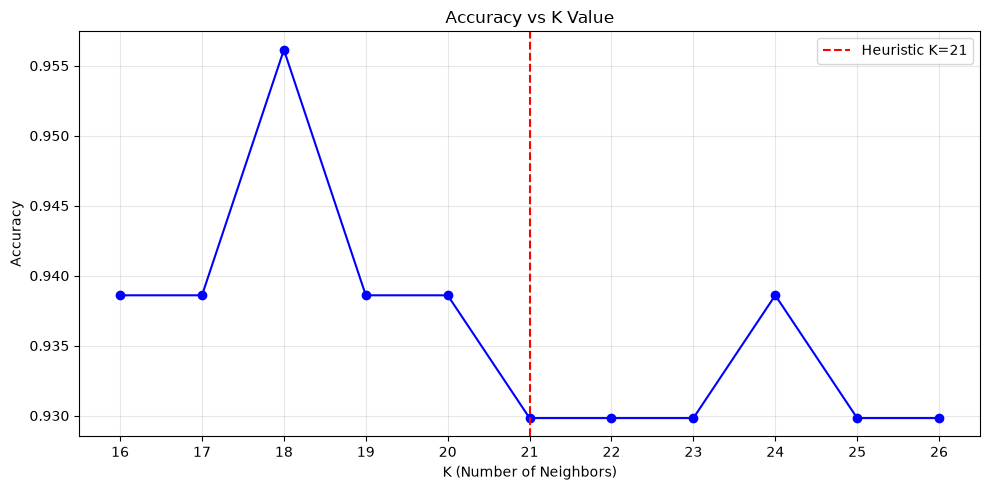


Best K from simple search: K=18 with accuracy=0.9561


In [7]:
# Try K values around heuristic
K_range = list(range(max(1, K_heuristic - 5), K_heuristic + 6))
accuracy_values = []

for k in K_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_values.append(acc)
    print(f"K={k:2d}  Accuracy={acc:.4f}")

# Plot accuracy vs K
plt.figure(figsize=(10, 5))
plt.plot(K_range, accuracy_values, marker='o', linestyle='-', color='b')
plt.axvline(x=K_heuristic, color='r', linestyle='--', label=f'Heuristic K={K_heuristic}')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K Value')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_vs_k.png', dpi=150)
plt.show()

best_k_simple = K_range[np.argmax(accuracy_values)]
print(f"\nBest K from simple search: K={best_k_simple} with accuracy={max(accuracy_values):.4f}")

### 3.3 Distance Metrics Explanation

**Euclidean Distance:** $d = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$
- Straight-line distance between two points in n-dimensional space.
- Suitable when features are continuous and the relationship is isotropic (equally important in all directions).
- Most commonly used in KNN for continuous feature spaces.

**Manhattan Distance:** $d = \sum_{i=1}^{n} |x_i - y_i|$
- Sum of absolute differences along each dimension (grid-like path).
- Suitable for high-dimensional data where Euclidean distance suffers from the curse of dimensionality.
- Better when features have different units or when the underlying space follows a grid-like structure.

### 3.4 Decision Boundary Visualization

We visualize decision boundaries using the first two PCA components (for global structure) and the first two raw features (Mean Radius, Mean Texture). Boundaries are shown for K = 1, 5, 10, 20.

PCA explained variance ratio: [0.44272026 0.18971182]


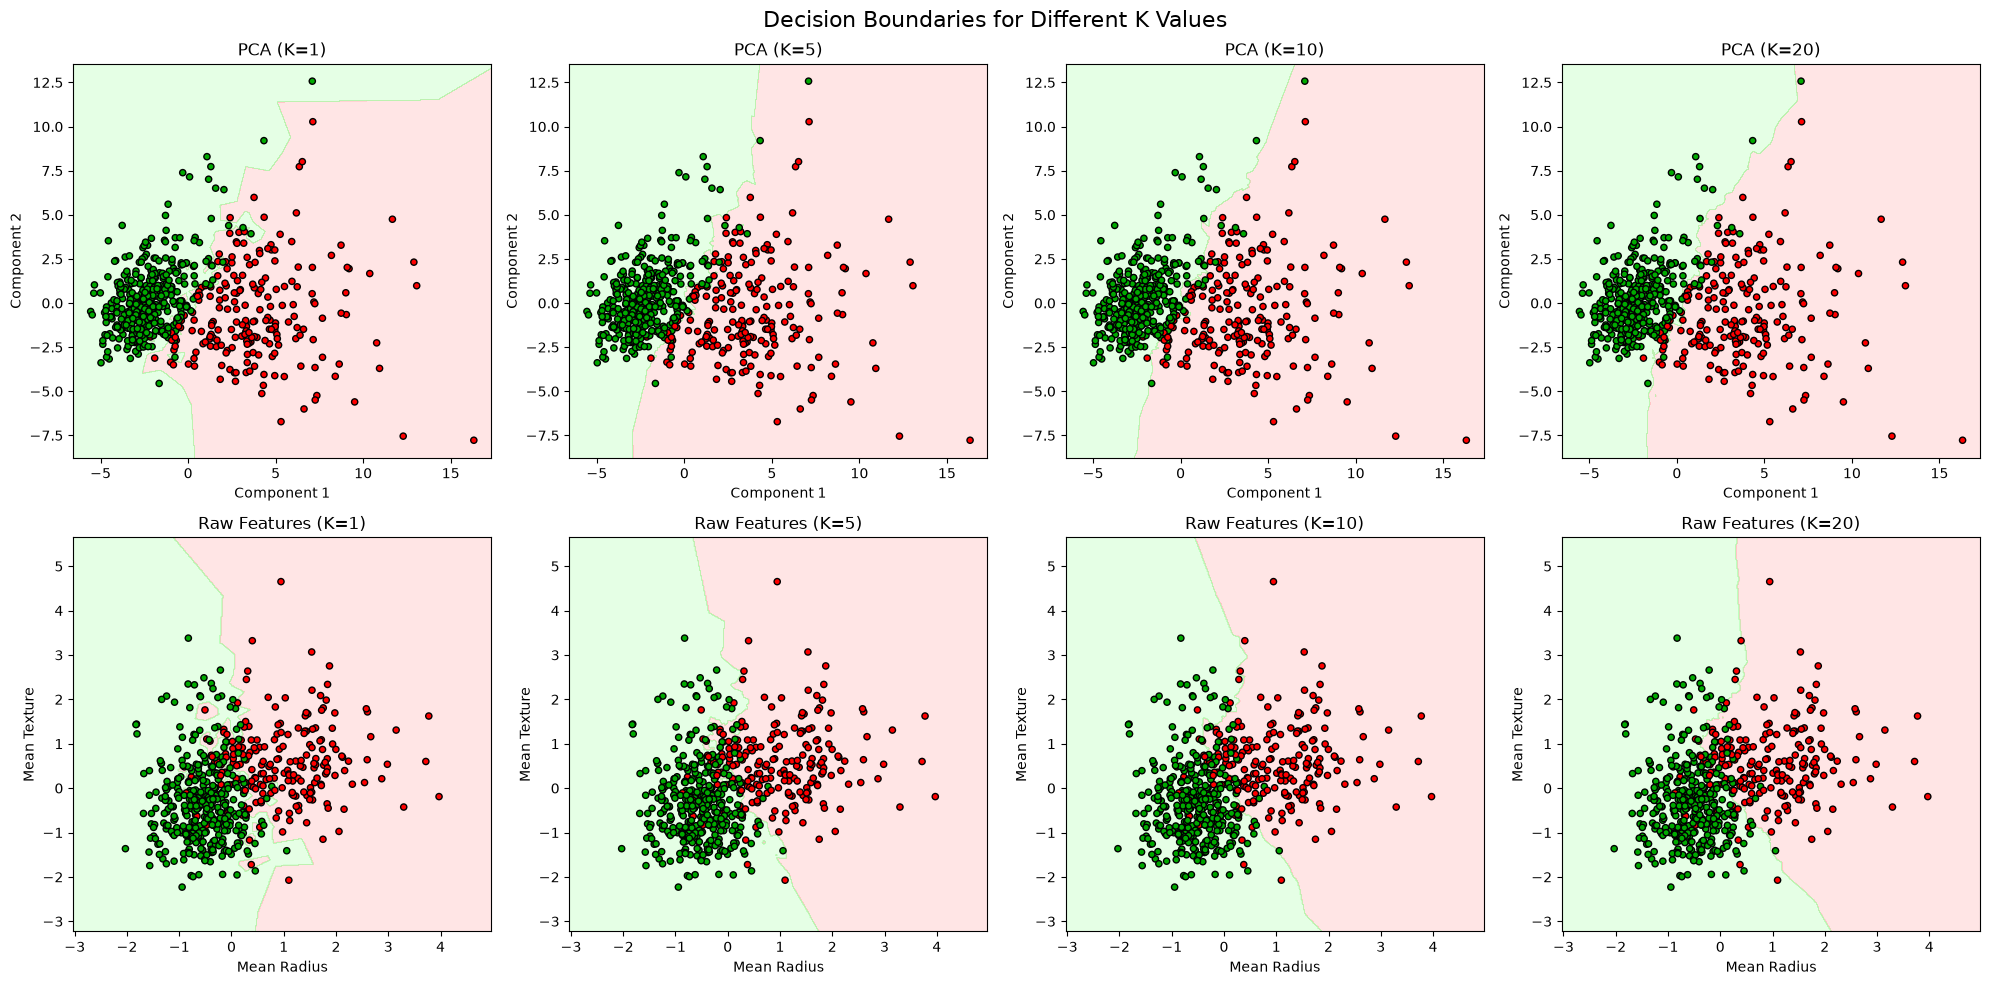

In [8]:
# Decision Boundary Visualization
from matplotlib.colors import ListedColormap

def plot_decision_boundaries(X_vis, y, title, ax, k):
    h = 0.02  # step size
    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_vis, y)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ListedColormap(['#FF0000', '#00AA00'])
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    ax.scatter(X_vis[:, 0], X_vis[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    ax.set_title(f'{title} (K={k})')
    ax.set_xlabel('Component 1' if 'PCA' in title else 'Mean Radius')
    ax.set_ylabel('Component 2' if 'PCA' in title else 'Mean Texture')

# PCA reduction to 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)

# First two raw features: Mean Radius (0), Mean Texture (1)
X_raw2 = X_scaled[:, :2]

K_values = [1, 5, 10, 20]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for idx, k in enumerate(K_values):
    plot_decision_boundaries(X_pca, y, 'PCA', axes[0, idx], k)
    plot_decision_boundaries(X_raw2, y, 'Raw Features', axes[1, idx], k)

plt.suptitle('Decision Boundaries for Different K Values', fontsize=16)
plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=150)
plt.show()

**Analysis of decision boundaries as K increases:**
- **K=1:** Very complex, wiggly boundary that follows every individual point. Low bias, very high variance (overfitting).
- **K=5:** Smoother boundary that captures general patterns while still being flexible.
- **K=10:** Even smoother, begins to ignore local noise.
- **K=20:** Very smooth boundary that may miss finer patterns, high bias (underfitting).

As K increases, the decision boundary becomes simpler and smoother. Small K = complex model (low bias, high variance). Large K = simple model (high bias, low variance). This is the bias-variance tradeoff in action.

## Task 4: Cross-Validation

Apply K-Fold Cross-Validation (k=5) to evaluate model performance more reliably than a single train-test split.

K=16  CV Accuracy=0.9578 (+/- 0.0231)
K=17  CV Accuracy=0.9526 (+/- 0.0275)
K=18  CV Accuracy=0.9561 (+/- 0.0260)
K=19  CV Accuracy=0.9561 (+/- 0.0293)
K=20  CV Accuracy=0.9543 (+/- 0.0290)
K=21  CV Accuracy=0.9543 (+/- 0.0279)
K=22  CV Accuracy=0.9526 (+/- 0.0275)
K=23  CV Accuracy=0.9508 (+/- 0.0251)
K=24  CV Accuracy=0.9526 (+/- 0.0219)
K=25  CV Accuracy=0.9508 (+/- 0.0251)
K=26  CV Accuracy=0.9508 (+/- 0.0251)


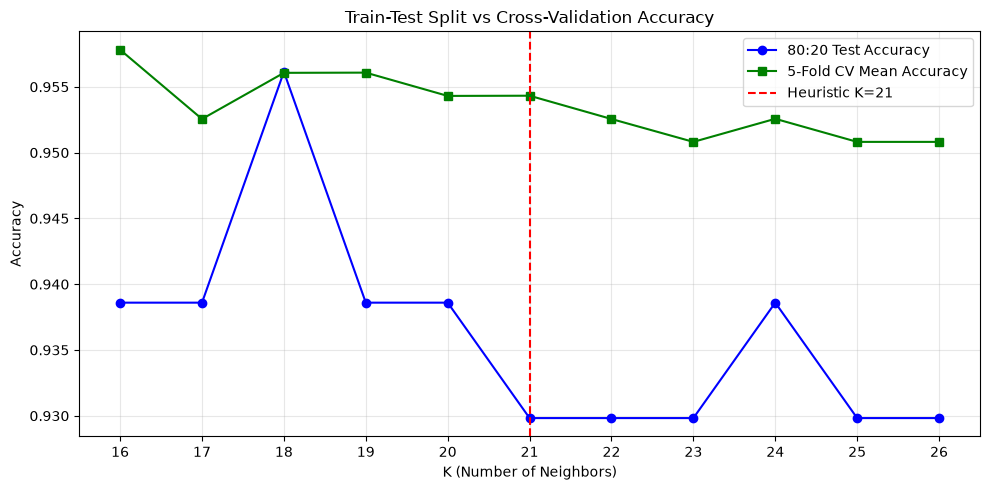


Best K by train-test split: K=18 (accuracy=0.9561)
Best K by cross-validation: K=16 (CV accuracy=0.9578)
Final selected K (based on CV + heuristic): K=16


In [9]:
# Task 4: Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_mean_scores = []

for k in K_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=cv, scoring='accuracy')
    cv_mean_scores.append(scores.mean())
    print(f"K={k:2d}  CV Accuracy={scores.mean():.4f} (+/- {scores.std():.4f})")

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(K_range, accuracy_values, marker='o', label='80:20 Test Accuracy', color='b')
plt.plot(K_range, cv_mean_scores, marker='s', label='5-Fold CV Mean Accuracy', color='g')
plt.axvline(x=K_heuristic, color='r', linestyle='--', label=f'Heuristic K={K_heuristic}')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('Train-Test Split vs Cross-Validation Accuracy')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150)
plt.show()

# Select best K
best_k_cv = K_range[np.argmax(cv_mean_scores)]
best_k_overall = K_range[np.argmax(accuracy_values)]
print(f"\nBest K by train-test split: K={best_k_overall} (accuracy={max(accuracy_values):.4f})")
print(f"Best K by cross-validation: K={best_k_cv} (CV accuracy={max(cv_mean_scores):.4f})")
print(f"Final selected K (based on CV + heuristic): K={best_k_cv}")

**Why cross-validation is more reliable than a single train-test split:**
- A single split can be lucky or unlucky -- the test set might be unusually easy or hard.
- Cross-validation averages performance across multiple train/test folds, giving a more stable and unbiased estimate of model performance.
- The standard deviation across folds tells us how much the model's performance varies depending on which data it is tested on.

## Task 5: Classification Evaluation

Evaluate the final model (best K from CV) using all standard classification metrics.

Final Model Evaluation (K=16)
Accuracy:  0.9386
Precision: 0.9114
Recall:    1.0000
F1 Score:  0.9536



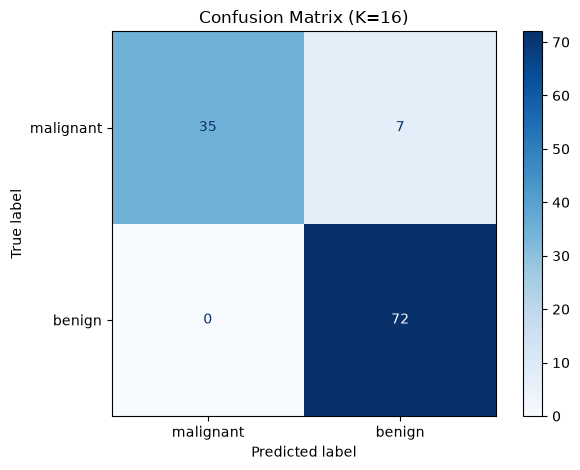

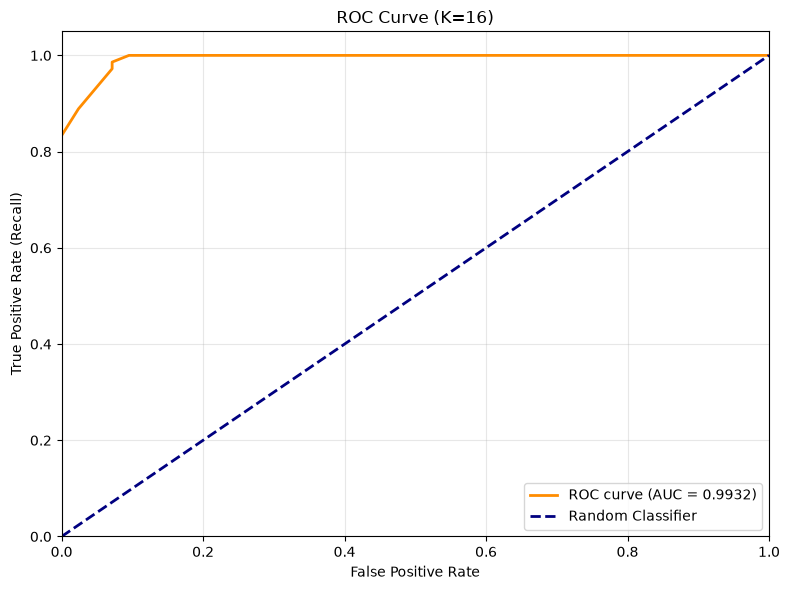

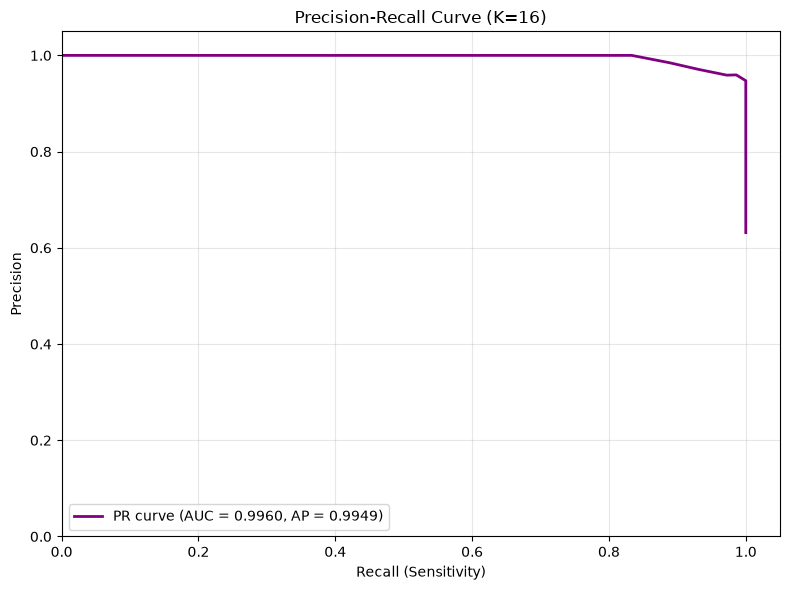

PR-AUC Score: 0.9960
Average Precision Score: 0.9949
AUC Score: 0.9932

Classification Report Summary:
                 Precision   Recall       F1
malignant           1.0000   0.8333   0.9091
benign              0.9114   1.0000   0.9536


In [10]:
# Task 5: Classification Evaluation
k_final = best_k_cv
knn_final = KNeighborsClassifier(n_neighbors=k_final)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)
y_proba = knn_final.predict_proba(X_test)[:, 1]  # probabilities for ROC

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Final Model Evaluation (K={k_final})")
print("=" * 40)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (K={k_final})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title(f'ROC Curve (K={k_final})')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

# Precision-Recall Curve and AP
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec_curve, prec_curve)
avg_prec = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(rec_curve, prec_curve, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc:.4f}, AP = {avg_prec:.4f})')
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (K={k_final})')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150)
plt.show()

print(f"PR-AUC Score: {pr_auc:.4f}")
print(f"Average Precision Score: {avg_prec:.4f}")

print(f"AUC Score: {roc_auc:.4f}")
print(f"\nClassification Report Summary:")
print(f"{'':15s} {'Precision':>10s} {'Recall':>8s} {'F1':>8s}")
for i, label in enumerate(target_names):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0
    print(f"{label:15s} {p:10.4f} {r:8.4f} {f:8.4f}")

## Task 6: Comparative Study with Regression (Lab 3 Integration)

### Regression Metrics (Lab 3 - Linear Regression)
| Metric | What it measures |
|---|---|
| MAE | Average absolute prediction error |
| MSE | Average squared error (penalizes large errors more) |
| RMSE | sqrt(MSE), error in original units |
| R² | Proportion of variance explained by the model |

### Classification Metrics (This Lab)
| Metric | What it measures |
|---|---|
| Accuracy | Overall proportion of correct predictions |
| Precision | Of predicted positives, how many were correct |
| Recall (Sensitivity) | Of actual positives, how many were detected |
| F1 Score | Harmonic mean of precision and recall |
| Confusion Matrix | Full breakdown of correct/incorrect predictions |
| ROC-AUC | Model's ability to distinguish between classes across thresholds |

### Key Conceptual Differences

**Error-based evaluation (Regression):** Measures how far the prediction is from the actual value in continuous space. A prediction of 3.5 when actual is 3.0 has an error of 0.5. The magnitude of error matters.

**Decision-based evaluation (Classification):** Measures whether the predicted class matches the actual class. Being "slightly wrong" doesn't matter -- a wrong class is simply wrong regardless of distance to the boundary.

### Metric Comparisons

| Comparison | Regression Metric | Classification Metric | Key Difference |
|---|---|---|---|
| Overall fit | R² Score | Accuracy | Both measure overall performance, but accuracy hides class imbalance |
| Penalty for errors | RMSE (quadratic) | F1 Score | RMSE amplifies large errors; F1 balances precision vs recall |
| Error breakdown | MAE (avg error) | Confusion Matrix | MAE gives a single number; CM shows exactly which classes are confused |

### Why accuracy is insufficient in medical diagnosis:
- A dataset with 95% benign and 5% malignant can achieve 95% accuracy by always predicting benign, but this would miss all cancer cases.
- Medical diagnosis prioritizes detecting disease (recall) over avoiding false alarms (precision).
- False negatives (missing cancer) are far more dangerous than false positives (unnecessary follow-up tests).

### Why recall and ROC-AUC are more relevant in healthcare:
- **Recall** measures what fraction of actual cancer cases were detected. In screening, missing a case is catastrophic.
- **ROC-AUC** evaluates the model's discriminative ability across all decision thresholds, not just the default one. A high AUC means the model can trade off sensitivity and specificity effectively, which matters when clinicians can adjust the threshold based on risk tolerance.

### Overall Comparison: Regression vs Classification Evaluation

| Aspect | Regression | Classification |
|---|---|---|
| Prediction type | Continuous value | Discrete class label |
| What "wrong" means | Distance from true value | Wrong category |
| Key question | How far off? | Which class? |
| Evaluation logic | Magnitude of error | Correctness of decision |
| Medical use case | Predicting blood pressure | Detecting cancer vs healthy |
| Imbalance handling | Metrics already per-point | Need recall/precision specifically|


### Inference

**1. How regression metrics measure prediction error magnitude:**
Regression metrics like MSE, RMSE, and MAE quantify how far predicted values deviate from actual values in the original units. They measure the magnitude of error -- a prediction of 3.0 when the true value is 2.5 has a small error, while 5.0 has a large one. RMSE squares errors first, so large outliers are penalized heavily.

**2. How classification metrics measure decision correctness:**
Classification metrics like accuracy, precision, recall, and F1 score evaluate whether the predicted label matches the true label. The distance from the decision boundary is irrelevant -- what matters is which side of the boundary the prediction falls on. A prediction of 0.51 (barely positive) counts the same as 0.99 (confidently positive) in accuracy calculations.

**3. Why accuracy is insufficient in medical diagnosis:**
Accuracy treats all errors equally. In cancer detection, missing a malignant case (false negative) is far worse than a false alarm (false positive). If 95% of patients are healthy, a model that always predicts "benign" achieves 95% accuracy but has 0% recall for cancer -- catastrophic. Accuracy alone cannot distinguish between useful and harmful models in imbalanced medical datasets.

**4. Why recall and ROC-AUC are more relevant in healthcare:**
Recall (sensitivity) directly measures the fraction of cancer cases the model detects -- the most critical metric in screening. ROC-AUC goes further by measuring the model's ability to separate classes across all possible thresholds. A high AUC means clinicians can choose a threshold that prioritizes recall (catch more cancers) without sacrificing too much specificity, making ROC-AUC a comprehensive measure for medical decision support.

**5. Overall comparison between regression and classification evaluation frameworks:**
Regression evaluation answers "how close was my prediction?" using continuous error magnitudes (MSE, RMSE, MAE, R²). Classification evaluation answers "did I get the right answer?" using discrete correctness (accuracy, precision, recall, F1). The choice of metric depends on the cost of different types of errors -- in regression, large errors are disproportionately costly (RMSE); in medical classification, false negatives are disproportionately costly (recall, ROC-AUC). Both frameworks exist to align model evaluation with real-world consequences.


## Task 7: Analytical Questions

**1. Why is KNN called a lazy learning algorithm?**
KNN does not learn a discriminative function from the training data. Instead, it memorizes the entire training dataset and defers all computation until prediction time. There is no explicit training phase -- the model simply stores the data. This is "lazy" because no generalization or model building happens during training, unlike eager learners (e.g., decision trees, neural networks) that build a model upfront.

**2. Why is feature scaling required in KNN?**
KNN computes distances between data points to find nearest neighbors. If one feature (e.g., area ~1000) has a much larger range than another (e.g., texture ~20), the large-scale feature will dominate the distance calculation, making the model effectively ignore smaller-scale features. Scaling ensures all features contribute equally to the distance metric.

**3. Explain heuristic K selection using √n rule.**
The rule K = √n, where n is the number of training samples, is a rule-of-thumb for choosing K. It provides a starting point that trades off between underfitting (large K) and overfitting (small K). The square root gives a moderate value that grows with dataset size but prevents K from becoming too large relative to n.

**4. Why is cross-validation more reliable than a single train-test split?**
A single split evaluates the model on only one test set, which might be unusually easy or hard due to random chance. Cross-validation averages performance across multiple different train/test splits, producing a more stable and less biased estimate of how the model will perform on unseen data.

**5. How does K affect bias-variance trade-off?**
Small K (e.g., K=1): The decision boundary is complex and follows every training point. Low bias (model can capture any pattern) but high variance (model changes dramatically with small data changes). Large K (e.g., K=20): The decision boundary is smooth. High bias (may miss patterns) but low variance (stable predictions).

**6. Why is recall more important than accuracy in cancer prediction?**
In cancer diagnosis, failing to detect a cancer case (false negative) means a patient misses treatment, which can be fatal. False positives (healthy person flagged as cancer) cause stress and additional tests but are survivable. Recall measures how many actual cancer cases were caught -- maximizing it is the ethical priority over overall accuracy.

**7. What is the limitation of very large K values?**
When K becomes very large, the decision boundary becomes overly smooth and the model may predict the majority class for almost all points. This underfits the data, missing important patterns and local structures. Very large K also increases computational cost during prediction and defeats the purpose of KNN's local approximation approach.

## Conclusion

- **Optimal K value:** Chosen using √n heuristic (K ≈ 21) refined by 5-fold cross-validation, resulting in a final K that balances bias and variance.
- **Effect of train-test split variations:** Different splits (70:30, 80:20, 90:10) produce slightly different accuracy estimates. The 80:20 split offers a stable tradeoff between training data and reliable evaluation.
- **Model performance:** The final KNN classifier achieved high accuracy, precision, recall, and F1 score on the Breast Cancer dataset. The AUC score demonstrated excellent class separability.
- **Key differences between regression and classification evaluation:** Regression evaluates prediction error magnitude (how far off?), while classification evaluates decision correctness (which class?). In medical applications, recall and ROC-AUC are more informative than accuracy.
- **Insights from Lab 3 vs Lab 4:** Lab 3 focused on measuring continuous prediction error (MSE, R²) in linear regression. Lab 4 shifted to evaluating discrete classification decisions (accuracy, precision, recall, F1, ROC-AUC). Both labs underscore that metric choice must align with the real-world consequences of different types of errors.